# Caries dataset audit + LabelMe→YOLO conversion + quality filtering (resolution + Laplacian-sharpness recalibration). Corresponds to article Section 2.2.2 (initial 2227→1645 filtering) and the F1-based threshold recalibration (threshold = 20.0).

This notebook (convertible using `jupytext --to notebook caries_dataset_pipeline.md`) performs the following:

1. Extracts the `.zip` file (located on Drive) **into runtime memory** (it is not saved on Drive).
2. Audit: discards images without LabelMe annotations (and vice versa).
3. Quality filtering: minimum resolution of 640x480 and discarding images with high blur.
4. Label statistics (totals, by classification, by view, by image).
5. Conversion from LabelMe to YOLO (detection), single class `Caries` (ID 0).
6. Image preprocessing using the provided pipeline.
7. Random before/after samples.
8. Final packaging of the resulting dataset and upload to Drive.

Expected structure inside the `.zip`:

```
Annotations/
    Darknet_YOLO/ {no_retractors,pilot,retractors}/{Frontal,Left_Lateral,Mandibular,Maxillary_Occlusal,Right_Lateral}
    Labelme/      {no_retractors,pilot,retractors}/{Frontal,Left_Lateral,Mandibular,Maxillary_Occlusal,Right_Lateral}
    MS_coco/      ...
    pascal-voc/   ...
Images/
    {no_retractors,pilot,retractors}/{Frontal,Left_Lateral,Mandibular,Maxillary_Occlusal,Right_Lateral}
```

## 0. Configuration and imports

In [ ]:
import os
import io
import json
import shutil
import zipfile
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ZIP_DRIVE_PATH = "/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Zenodo-Dataset Base/Dataset.zip"
OUTPUT_ZIP_DRIVE_PATH = "/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/Dataset-Filtrado.zip"

RUNTIME_ROOT = Path("/content/runtime_dataset")
if RUNTIME_ROOT.exists():
    shutil.rmtree(RUNTIME_ROOT)
RUNTIME_ROOT.mkdir(parents=True)

CLASSIFICATIONS = ["no_retractors", "pilot", "retractors"]
VIEWS = ["Frontal", "Left_Lateral", "Mandibular", "Maxillary_Occlusal", "Right_Lateral"]
ANNOTATION_FORMAT = "Labelme"
CLASS_NAMES = ["Caries"]

MIN_WIDTH, MIN_HEIGHT = 640, 480
BLUR_PERCENTILE = 5.0
BLUR_VARIANCE_THRESHOLD_FLOOR = 30.0
# NOTE: this floor (30.0) is later overridden by the metric-based recalibration in Cell 3E (final threshold = 20.0); kept here only for traceability of the original decision.

random.seed(42)
np.random.seed(42)

In [ ]:
BLUR_CACHE_PATH = Path("/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/blur_cache.csv")

## 1. Extracting the .zip file in runtime memory

In [ ]:
# Leemos el zip desde Drive a un buffer en memoria y extraemos directo al runtime (no a Drive)
with open(ZIP_DRIVE_PATH, "rb") as f:
    zip_bytes = io.BytesIO(f.read())

with zipfile.ZipFile(zip_bytes) as zf:
    zf.extractall(RUNTIME_ROOT)

print("Extraído en:", RUNTIME_ROOT)
for p in sorted(RUNTIME_ROOT.iterdir()):
    print(" -", p.name)

Extraído en: /content/runtime_dataset
 - Dataset


In [ ]:
# Detectar la raíz real (por si el zip trae una carpeta contenedora)
def find_dataset_root(root: Path) -> Path:
    if (root / "Annotations").exists() and (root / "Images").exists():
        return root
    for child in root.iterdir():
        if child.is_dir() and (child / "Annotations").exists() and (child / "Images").exists():
            return child
    raise FileNotFoundError("No se encontró la estructura Annotations/Images dentro del zip")

DATASET_ROOT = find_dataset_root(RUNTIME_ROOT)
IMAGES_ROOT = DATASET_ROOT / "Images"
LABELME_ROOT = DATASET_ROOT / "Annotations" / ANNOTATION_FORMAT
print("DATASET_ROOT:", DATASET_ROOT)

DATASET_ROOT: /content/runtime_dataset/Dataset


## 2. Audit — Match Image ↔ Label LabelMe

In [ ]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTENSIONS]

# registro de items: cada uno con imagen + json (si existe) + metadata
records = []
audit_discarded = {"sin_label": [], "sin_imagen": []}

for cls in CLASSIFICATIONS:
    for view in VIEWS:
        img_dir = IMAGES_ROOT / cls / view
        lbl_dir = LABELME_ROOT / cls / view

        imgs = {p.stem: p for p in list_images(img_dir)}
        jsons = {p.stem: p for p in (lbl_dir.glob("*.json") if lbl_dir.exists() else [])}

        all_stems = set(imgs) | set(jsons)
        for stem in all_stems:
            img_p = imgs.get(stem)
            json_p = jsons.get(stem)
            if img_p is None:
                audit_discarded["sin_imagen"].append(str(json_p))
                continue
            if json_p is None:
                audit_discarded["sin_label"].append(str(img_p))
                continue
            records.append({
                "stem": stem,
                "classification": cls,
                "view": view,
                "image_path": img_p,
                "json_path": json_p,
            })

print(f"Pares imagen-label válidos: {len(records)}")
print(f"Descartadas por falta de label: {len(audit_discarded['sin_label'])}")
print(f"Jsons sin imagen asociada: {len(audit_discarded['sin_imagen'])}")

Pares imagen-label válidos: 2227
Descartadas por falta de label: 4038
Jsons sin imagen asociada: 18


## 3. Quality Filter — Minimum Resolution and Blur

Caché de blur guardada en: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/blur_cache.csv
Pasan resolución mínima: 2208 / descartadas: 19


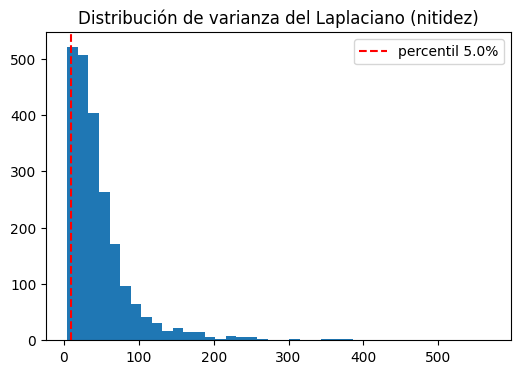

Umbral de blur adoptado: 30.00 (percentil 5.0% = 9.01, piso = 30.0)
Pasan control de calidad final: 1262
Descartadas por calidad (resolución + blur): 965


,stem,classification,view,reason
0,anonymous_003-008-727-00_1729516303649_Left_La...,no_retractors,Left_Lateral,resolucion_baja(787x442)
1,anonymous_003-008-1052-00_1731329608354_Left_L...,no_retractors,Left_Lateral,resolucion_baja(745x418)
2,anonymous_003-008-1140-00_1732538036389_Left_L...,no_retractors,Left_Lateral,resolucion_baja(819x460)
3,anonymous_003-008-977-00_1730895561784_Left_La...,no_retractors,Left_Lateral,resolucion_baja(741x416)
4,anonymous_003-008-860-00_1730202956330_Left_La...,no_retractors,Left_Lateral,resolucion_baja(727x408)
5,anonymous_003-008-1116-00_1732364867658_Left_L...,no_retractors,Left_Lateral,resolucion_baja(779x438)
6,anonymous_003-008-935-00_1730724141122_Right_L...,no_retractors,Right_Lateral,resolucion_baja(727x408)
7,anonymous_003-008-1437-01_1734003718169_Left_L...,retractors,Left_Lateral,resolucion_baja(814x457)
8,anonymous_003-008-859-01_1730202467399_Left_La...,retractors,Left_Lateral,resolucion_baja(727x408)
9,anonymous_003-008-1051-01_1731329026684_Left_L...,retractors,Left_Lateral,resolucion_baja(748x420)


In [ ]:
def blur_variance(image: np.ndarray) -> float:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# 1er paso: resolución mínima (esto sí es un corte duro, no depende de distribución)
if BLUR_CACHE_PATH.exists():
    print(f"Cargando caché de blur: {BLUR_CACHE_PATH}")
    df_cache = pd.read_csv(BLUR_CACHE_PATH)
    cache_por_stem = df_cache.set_index("stem").to_dict("index")
    res_ok, res_discarded = [], []
    for rec in records:
        c = cache_por_stem.get(rec["stem"])
        if c is None:
            continue  # no debería pasar si records no cambió
        if c["descartada"]:
            res_discarded.append({**rec, "reason": c["reason"]})
        else:
            rec = dict(rec)
            rec["width"], rec["height"], rec["blur_var"] = c["width"], c["height"], c["blur_var"]
            res_ok.append(rec)
else:
    res_ok, res_discarded = [], []
    for rec in records:
        img = cv2.imread(str(rec["image_path"]))
        if img is None:
            res_discarded.append({**rec, "reason": "no_legible"})
            continue
        h, w = img.shape[:2]
        if w < MIN_WIDTH or h < MIN_HEIGHT:
            res_discarded.append({**rec, "reason": f"resolucion_baja({w}x{h})"})
            continue
        rec = dict(rec)
        rec["width"], rec["height"] = w, h
        rec["blur_var"] = blur_variance(img)
        res_ok.append(rec)

    filas_cache = (
        [{"stem": r["stem"], "width": r["width"], "height": r["height"],
          "blur_var": r["blur_var"], "descartada": False, "reason": None} for r in res_ok] +
        [{"stem": r["stem"], "width": r.get("width"), "height": r.get("height"),
          "blur_var": r.get("blur_var"), "descartada": True, "reason": r["reason"]} for r in res_discarded]
    )
    pd.DataFrame(filas_cache).to_csv(BLUR_CACHE_PATH, index=False)
    print(f"Caché de blur guardada en: {BLUR_CACHE_PATH}")

print(f"Pasan resolución mínima: {len(res_ok)} / descartadas: {len(res_discarded)}")

# 2do paso: umbral de blur derivado de la propia distribución (percentil bajo),
# en vez de un número fijo arbitrario. Se ve primero la distribución para elegir bien.
blur_values = np.array([r["blur_var"] for r in res_ok])
plt.figure(figsize=(6, 4))
plt.hist(blur_values, bins=40)
plt.axvline(np.percentile(blur_values, BLUR_PERCENTILE), color="red", linestyle="--",
            label=f"percentil {BLUR_PERCENTILE}%")
plt.title("Distribución de varianza del Laplaciano (nitidez)")
plt.legend()
plt.show()

blur_threshold = max(float(np.percentile(blur_values, BLUR_PERCENTILE)), BLUR_VARIANCE_THRESHOLD_FLOOR)
print(f"Umbral de blur adoptado: {blur_threshold:.2f} "
      f"(percentil {BLUR_PERCENTILE}% = {np.percentile(blur_values, BLUR_PERCENTILE):.2f}, "
      f"piso = {BLUR_VARIANCE_THRESHOLD_FLOOR})")

quality_ok, quality_discarded = [], list(res_discarded)
for rec in res_ok:
    if rec["blur_var"] < blur_threshold:
        quality_discarded.append({**rec, "reason": f"blur_alto(var={rec['blur_var']:.1f})"})
    else:
        quality_ok.append(rec)

print(f"Pasan control de calidad final: {len(quality_ok)}")
print(f"Descartadas por calidad (resolución + blur): {len(quality_discarded)}")
pd.DataFrame(quality_discarded)[["stem", "classification", "view", "reason"]].head(20) if quality_discarded else "Sin descartes"

### CELL 3B — Visual inspection around the threshold:

In [ ]:
import random
random.seed(42)

# Solo registros que sí tienen blur_var
todos_con_blur = [r for r in quality_ok if "blur_var" in r] + [r for r in quality_discarded if "blur_var" in r]

# Casos cercanos al umbral: ajusta ventana si quieres
margen_inferior = max(0, blur_threshold - 15)
margen_superior = blur_threshold + 15

candidatos_revision = [
    r for r in todos_con_blur
    if margen_inferior <= r["blur_var"] <= margen_superior
]

muestra_revision = random.sample(candidatos_revision, min(80, len(candidatos_revision)))

df_revision_blur = pd.DataFrame([
    {
        "idx": i,
        "stem": r["stem"],
        "classification": r["classification"],
        "view": r["view"],
        "blur_var": float(r["blur_var"]),
        "image_path": str(r["image_path"]),
        "decision_sugerida": "utilizable" if r["blur_var"] >= blur_threshold else "desenfoque_severo",
        "revisor1": "",
        "revisor2": "",
        "consenso": "",
        "comentarios": ""
    }
    for i, r in enumerate(muestra_revision)
])

display(df_revision_blur[["idx", "stem", "classification", "view", "blur_var", "decision_sugerida"]].sort_values("blur_var"))
print(f"Total para revisión manual: {len(df_revision_blur)}")
print(f"Ventana usada: [{margen_inferior:.2f}, {margen_superior:.2f}] con umbral {blur_threshold:.2f}")

,idx,stem,classification,view,blur_var,decision_sugerida
58,58,anonymous-maxillaryView-1727757445006,pilot,Maxillary_Occlusal,15.019266,desenfoque_severo
57,57,anonymous_003-007-1097-01_1732258152530_Maxill...,retractors,Maxillary_Occlusal,15.444939,desenfoque_severo
47,47,anonymous_003-007-700-01_1729325366305_Maxilla...,retractors,Maxillary_Occlusal,15.552291,desenfoque_severo
19,19,anonymous_003-008-1200-00_1732786546715_Maxill...,no_retractors,Maxillary_Occlusal,15.817905,desenfoque_severo
4,4,anonymous_003_007_423_00_1728457856133_Left_La...,no_retractors,Left_Lateral,16.170804,desenfoque_severo
...,...,...,...,...,...,...
7,7,anonymous-mandibularView-1727761912039,pilot,Mandibular,43.932311,utilizable
20,20,anonymous_003-007-1444-00_1734065185373_Mandib...,no_retractors,Mandibular,44.459292,utilizable
5,5,anonymous_003-007-584-01_1728978916496_Mandibu...,retractors,Mandibular,44.584817,utilizable
46,46,anonymous_003-007-867-01_1730261098640_Mandibu...,retractors,Mandibular,44.868185,utilizable


Total para revisión manual: 80
Ventana usada: [15.00, 45.00] con umbral 30.00


### CELL 3C — Sensitivity analysis (does not require manual review):

In [ ]:
# One-time manual annotation step — do not re-run unless redoing the human review; outputs are already saved to revision_manual_blur_consenso.csv."

from IPython.display import display, clear_output
import ipywidgets as widgets
from PIL import Image
import os

REVISION_CSV_PATH = "/content/revision_manual_blur.csv"

if os.path.exists(REVISION_CSV_PATH):
    df_revision_blur = pd.read_csv(REVISION_CSV_PATH)
    print("Se cargó una revisión previa desde CSV.")
else:
    df_revision_blur = df_revision_blur.copy()

current_idx = 0

out = widgets.Output()

dropdown_campo = widgets.Dropdown(
    options=["revisor1", "revisor2", "consenso"],
    value="revisor1",
    description="Campo:"
)

toggle_decision = widgets.ToggleButtons(
    options=[
        ("Utilizable", "utilizable"),
        ("Desenfoque severo", "desenfoque_severo")
    ],
    description="Clase:"
)

comentarios = widgets.Textarea(
    value="",
    description="Notas:",
    layout=widgets.Layout(width="95%", height="80px")
)

btn_guardar = widgets.Button(description="Guardar decisión", button_style="success")
btn_anterior = widgets.Button(description="Anterior")
btn_siguiente = widgets.Button(description="Siguiente")
btn_exportar = widgets.Button(description="Exportar CSV", button_style="info")

label_estado = widgets.HTML()
label_meta = widgets.HTML()

def cargar_fila(i):
    global current_idx
    current_idx = i
    row = df_revision_blur.iloc[current_idx]

    valor_actual = row[dropdown_campo.value]
    if pd.isna(valor_actual) or valor_actual == "":
        toggle_decision.value = None
    else:
        toggle_decision.value = valor_actual

    comentarios.value = "" if pd.isna(row["comentarios"]) else str(row["comentarios"])

    label_estado.value = (
        f"<b>Registro {current_idx + 1} / {len(df_revision_blur)}</b>"
    )

    label_meta.value = (
        f"stem: <b>{row['stem']}</b><br>"
        f"classification: {row['classification']}<br>"
        f"view: {row['view']}<br>"
        f"blur_var: {row['blur_var']:.2f}<br>"
        f"sugerida: {row['decision_sugerida']}<br>"
        f"revisor1: {row['revisor1']}<br>"
        f"revisor2: {row['revisor2']}<br>"
    )

    with out:
        clear_output(wait=True)
        img = Image.open(row["image_path"])
        display(img)

def guardar_actual(_=None):
    global df_revision_blur
    if toggle_decision.value is not None:
        df_revision_blur.at[current_idx, dropdown_campo.value] = toggle_decision.value
    df_revision_blur.at[current_idx, "comentarios"] = comentarios.value
    df_revision_blur.to_csv(REVISION_CSV_PATH, index=False)

def siguiente(_):
    guardar_actual()
    if current_idx < len(df_revision_blur) - 1:
        cargar_fila(current_idx + 1)

def anterior(_):
    guardar_actual()
    if current_idx > 0:
        cargar_fila(current_idx - 1)

def exportar(_):
    guardar_actual()
    df_revision_blur.to_csv(REVISION_CSV_PATH, index=False)
    print(f"CSV guardado en: {REVISION_CSV_PATH}")

def cambiar_campo(change):
    if change["name"] == "value":
        cargar_fila(current_idx)

btn_guardar.on_click(guardar_actual)
btn_siguiente.on_click(siguiente)
btn_anterior.on_click(anterior)
btn_exportar.on_click(exportar)
dropdown_campo.observe(cambiar_campo)

ui = widgets.VBox([
    label_estado,
    label_meta,
    dropdown_campo,
    toggle_decision,
    comentarios,
    widgets.HBox([btn_guardar, btn_anterior, btn_siguiente, btn_exportar]),
    out
])

display(ui)
cargar_fila(0)

### CELL 3D. Consolidation and Saving of the Final Consensus

In [ ]:
import os
import numpy as np
import pandas as pd

REVISION_CSV_PATH = "/content/revision_manual_blur.csv"
REVISION_CONSENSO_CSV_PATH = "/content/revision_manual_blur_consenso.csv"

# Opcional: ruta en Drive para persistir en la nube
DRIVE_CONSENSO_CSV_PATH = "/content/drive/MyDrive/Proyecto-Titulacion/Corpus-Caries/Caries-Deteccion/Dataset/revision_manual_blur_consenso.csv"

if not os.path.exists(REVISION_CSV_PATH):
    raise FileNotFoundError(f"No existe {REVISION_CSV_PATH}. Primero completa la revisión en 3c.")

df_consenso = pd.read_csv(REVISION_CSV_PATH)

# Normalización
for col in ["revisor1", "revisor2", "consenso"]:
    if col not in df_consenso.columns:
        df_consenso[col] = ""
    df_consenso[col] = (
        df_consenso[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

validas = {"utilizable", "desenfoque_severo"}

df_consenso["r1_valido"] = df_consenso["revisor1"].isin(validas)
df_consenso["r2_valido"] = df_consenso["revisor2"].isin(validas)
df_consenso["ambos_validos"] = df_consenso["r1_valido"] & df_consenso["r2_valido"]

# Consenso automático cuando ambos coinciden
df_consenso["consenso_propuesto"] = np.where(
    df_consenso["ambos_validos"] & (df_consenso["revisor1"] == df_consenso["revisor2"]),
    df_consenso["revisor1"],
    ""
)

# Marcar conflictos
df_consenso["conflicto"] = (
    df_consenso["ambos_validos"] &
    (df_consenso["revisor1"] != df_consenso["revisor2"])
)

# Guardar consenso final:
# 1) si ya existe consenso manual, se respeta
# 2) si no existe y hay acuerdo automático, se autocompleta
mask_sin_consenso = ~df_consenso["consenso"].isin(validas)
mask_con_acuerdo = df_consenso["consenso_propuesto"].isin(validas)

df_consenso.loc[mask_sin_consenso & mask_con_acuerdo, "consenso"] = \
    df_consenso.loc[mask_sin_consenso & mask_con_acuerdo, "consenso_propuesto"]

# Marcar pendientes reales: sin consenso final todavía
df_consenso["pendiente_consenso"] = ~df_consenso["consenso"].isin(validas)

# Resumen
n_total = len(df_consenso)
n_r1 = int(df_consenso["r1_valido"].sum())
n_r2 = int(df_consenso["r2_valido"].sum())
n_ambos = int(df_consenso["ambos_validos"].sum())
n_acuerdos = int(df_consenso["consenso_propuesto"].isin(validas).sum())
n_conflictos = int(df_consenso["conflicto"].sum())
n_finales = int(df_consenso["consenso"].isin(validas).sum())
n_pendientes = int(df_consenso["pendiente_consenso"].sum())

agreement_pct = (100 * n_acuerdos / n_ambos) if n_ambos > 0 else np.nan

print(f"Total de imágenes en revisión: {n_total}")
print(f"Revisor 1 completó: {n_r1}")
print(f"Revisor 2 completó: {n_r2}")
print(f"Casos con ambos revisores: {n_ambos}")
print(f"Acuerdos automáticos: {n_acuerdos}")
print(f"Conflictos entre revisores: {n_conflictos}")
print(f"Consensos finales guardados: {n_finales}")
print(f"Pendientes de consenso: {n_pendientes}")
print(f"Porcentaje de acuerdo observado: {agreement_pct:.2f}%" if n_ambos > 0 else "Sin casos comparables aún")

# Tabla de conflictos / pendientes
df_pendientes = df_consenso.loc[
    df_consenso["pendiente_consenso"],
    ["idx", "stem", "classification", "view", "blur_var", "revisor1", "revisor2", "consenso", "comentarios"]
].sort_values("blur_var")

print("\nPendientes de resolver manualmente:")
display(df_pendientes)

# Resumen del consenso final
df_resumen_consenso = (
    df_consenso[df_consenso["consenso"].isin(validas)]["consenso"]
    .value_counts()
    .rename_axis("consenso")
    .reset_index(name="n")
)

print("\nDistribución del consenso final:")
display(df_resumen_consenso)

# Guardado local en runtime
df_consenso.to_csv(REVISION_CONSENSO_CSV_PATH, index=False)
print(f"\nConsenso final guardado en local: {REVISION_CONSENSO_CSV_PATH}")

# Guardado opcional en Drive
try:
    os.makedirs(os.path.dirname(DRIVE_CONSENSO_CSV_PATH), exist_ok=True)
    df_consenso.to_csv(DRIVE_CONSENSO_CSV_PATH, index=False)
    print(f"Consenso final guardado en Drive: {DRIVE_CONSENSO_CSV_PATH}")
except Exception as e:
    print(f"No se pudo guardar en Drive: {e}")

Total de imágenes en revisión: 80
Revisor 1 completó: 80
Revisor 2 completó: 80
Casos con ambos revisores: 80
Acuerdos automáticos: 69
Conflictos entre revisores: 11
Consensos finales guardados: 69
Pendientes de consenso: 11
Porcentaje de acuerdo observado: 86.25%

Pendientes de resolver manualmente:


,idx,stem,classification,view,blur_var,revisor1,revisor2,consenso,comentarios
58,58,anonymous-maxillaryView-1726736731821,pilot,Maxillary_Occlusal,15.434116,utilizable,desenfoque_severo,,NaN
69,69,anonymous_003-007-1452-00_1734075049818_Maxill...,no_retractors,Maxillary_Occlusal,15.507749,desenfoque_severo,utilizable,,NaN
64,64,anonymous_003-007-1359-00_1733722491507_Maxill...,no_retractors,Maxillary_Occlusal,15.958439,desenfoque_severo,utilizable,,NaN
66,66,anonymous_004-007-1028-00_1731221772302_Maxill...,no_retractors,Maxillary_Occlusal,19.658688,desenfoque_severo,utilizable,,NaN
32,32,anonymous_003_007_468_00_1728620859733_Maxilla...,no_retractors,Maxillary_Occlusal,21.477508,utilizable,desenfoque_severo,,NaN
43,43,anonymous_003_008_534_00_1728809131094_Mandibu...,no_retractors,Mandibular,24.948549,utilizable,desenfoque_severo,,NaN
28,28,anonymous-maxillaryView-1727762213007,pilot,Maxillary_Occlusal,25.512579,utilizable,desenfoque_severo,,NaN
13,13,anonymous_003-007-1477-00_1734160734308_Mandib...,no_retractors,Mandibular,28.611590,desenfoque_severo,utilizable,,NaN
11,11,anonymous-rightLateralView-1727070916155,pilot,Right_Lateral,31.351420,desenfoque_severo,utilizable,,NaN
45,45,anonymous-mandibularView-1726818342880,pilot,Mandibular,32.016463,desenfoque_severo,utilizable,,NaN



Distribución del consenso final:


,consenso,n
0,utilizable,66
1,desenfoque_severo,3



Consenso final guardado en local: /content/revision_manual_blur_consenso.csv
Consenso final guardado en Drive: /content/drive/MyDrive/Proyecto-Titulacion/Corpus-Caries/Caries-Deteccion/Dataset/revision_manual_blur_consenso.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Proyecto-Titulacion/Corpus-Caries/Caries-Deteccion/Dataset/revision_manual_blur_consenso.csv')

pendientes = df[df['consenso'].isna() | (df['consenso'].astype(str).str.strip() == '')]

print(f"Casos pendientes de consenso: {len(pendientes)}\n")
cols = ['stem', 'classification', 'view', 'blur_var', 'revisor1', 'revisor2']
print(pendientes[cols].to_string(index=False))

Casos pendientes de consenso: 11

                                                           stem classification               view  blur_var          revisor1          revisor2
                       anonymous-rightLateralView-1727070916155          pilot      Right_Lateral 31.351420 desenfoque_severo        utilizable
        anonymous_003-007-1477-00_1734160734308_Mandibular_View  no_retractors         Mandibular 28.611590 desenfoque_severo        utilizable
                          anonymous-maxillaryView-1727778085436          pilot Maxillary_Occlusal 36.682959 desenfoque_severo        utilizable
                          anonymous-maxillaryView-1727762213007          pilot Maxillary_Occlusal 25.512579        utilizable desenfoque_severo
 anonymous_003_007_468_00_1728620859733_Maxillary_Occlusal_View  no_retractors Maxillary_Occlusal 21.477508        utilizable desenfoque_severo
         anonymous_003_008_534_00_1728809131094_Mandibular_View  no_retractors         Mandibular 24.9

In [ ]:
# Ejemplo — reemplaza idx y valor por lo que acuerden para cada fila pendiente
resoluciones = {
    11: 'utilizable',   # o 'utilizable', según lo que acuerden
    13: 'desenfoque_severo',
    27: 'desenfoque_severo',
    28: 'utilizable',
    32: 'utilizable',
    43: 'utilizable',
    45: 'desenfoque_severo',
    58: 'utilizable',
    64: 'desenfoque_severo',
    66: 'desenfoque_severo',
    69: 'desenfoque_severo',

}

for idx, valor in resoluciones.items():
    df.loc[df['idx'] == idx, 'consenso'] = valor

print("Pendientes restantes:", df['consenso'].isna().sum())
df.to_csv('/content/drive/MyDrive/Proyecto-Titulacion/Corpus-Caries/Caries-Deteccion/Dataset/revision_manual_blur_consenso.csv', index=False)

Pendientes restantes: 0


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Proyecto-Titulacion/Corpus-Caries/Caries-Deteccion/Dataset/revision_manual_blur_consenso.csv')

# Verifica que ya no queden vacíos
print("Pendientes:", df['consenso'].isna().sum())

# Esto es lo importante: ¿el corte de 30.0 coincide con el juicio humano?
df['prediccion_umbral'] = df['blur_var'].apply(lambda v: 'utilizable' if v >= 30.0 else 'desenfoque_severo')
tabla = pd.crosstab(df['prediccion_umbral'], df['consenso'])
print(tabla)

aciertos = (df['prediccion_umbral'] == df['consenso']).sum()
print(f"Concordancia umbral 30.0 vs consenso humano: {aciertos}/{len(df)} = {100*aciertos/len(df):.1f}%")

Pendientes: 0
consenso           desenfoque_severo  utilizable
prediccion_umbral                               
desenfoque_severo                  6          38
utilizable                         3          33
Concordancia umbral 30.0 vs consenso humano: 39/80 = 48.8%


### CELL 3E. Recalibration of the blur threshold based on metrics (sensitivity/specificity/F1)

In [ ]:
# Use the human consensus from the 80 images (3D cell) to choose the
# blur_var threshold that best distinguishes “usable” from “severe blur,”
# instead of keeping the floor fixed at BLUR_VARIANCE_THRESHOLD_FLOOR = 30.0
# without favorable validation.

import pandas as pd
import numpy as np

REVISION_CONSENSO_CSV_PATH = "/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/revision_manual_blur_consenso.csv"

df_final = pd.read_csv(REVISION_CONSENSO_CSV_PATH)

# Solo filas con consenso final válido (utilizable / desenfoque_severo)
validas = {"utilizable", "desenfoque_severo"}
df_eval = df_final[df_final["consenso"].isin(validas)].copy()
print(f"Filas con consenso válido para recalibrar: {len(df_eval)} / {len(df_final)}")

# Clase positiva = "desenfoque_severo" (lo que el filtro debe detectar)
y_true = (df_eval["consenso"] == "desenfoque_severo").astype(int).to_numpy()
blur_var = df_eval["blur_var"].to_numpy()

def metricas_para_umbral(umbral, y_true, blur_var):
    # Predicción: blur_var < umbral -> se clasifica como "desenfoque_severo" (positivo)
    y_pred = (blur_var < umbral).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall de "desenfoque_severo"
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = (2 * precision * sensibilidad / (precision + sensibilidad)
          if (precision + sensibilidad) > 0 else 0.0)
    balanced_acc = (sensibilidad + especificidad) / 2

    return {
        "umbral": umbral, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "sensibilidad": sensibilidad, "especificidad": especificidad,
        "precision": precision, "f1": f1, "balanced_accuracy": balanced_acc,
    }

# Barrido de umbrales candidatos
umbrales_candidatos = list(range(10, 46, 5))  # 10, 15, 20, 25, 30, 35, 40, 45
filas_metricas = [metricas_para_umbral(u, y_true, blur_var) for u in umbrales_candidatos]
df_metricas = pd.DataFrame(filas_metricas)

print("\n--- Barrido de umbrales candidatos ---")
print(df_metricas.to_string(index=False))

# Criterio de selección: maximizar F1 (con balanced_accuracy como desempate)
df_metricas_ordenado = df_metricas.sort_values(
    ["f1", "balanced_accuracy"], ascending=False
).reset_index(drop=True)

UMBRAL_RECALIBRADO = float(df_metricas_ordenado.iloc[0]["umbral"])
print(f"\n🏆 Umbral recalibrado (máximo F1): {UMBRAL_RECALIBRADO}")
print(df_metricas_ordenado.iloc[0].to_string())

# Guardar la tabla completa para el artículo (sección de sensibilidad del blur)
RUTA_TABLA_RECALIBRACION = "/content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/tabla_recalibracion_blur.csv"
df_metricas.to_csv(RUTA_TABLA_RECALIBRACION, index=False)
print(f"\n📄 Tabla de recalibración guardada en: {RUTA_TABLA_RECALIBRACION}")

# --- Recalcular quality_ok / quality_discarded con el nuevo umbral,
#     reutilizando res_ok (ya tiene blur_var para las 2208 imágenes que
#     pasaron resolución) sin necesidad de releer el zip ni recalcular blur ---
blur_threshold = UMBRAL_RECALIBRADO
print(f"\nRecalculando quality_ok/quality_discarded con blur_threshold = {blur_threshold} ...")

quality_ok, quality_discarded = [], list(res_discarded)
for rec in res_ok:
    if rec["blur_var"] < blur_threshold:
        quality_discarded.append({**rec, "reason": f"blur_alto(var={rec['blur_var']:.1f})"})
    else:
        quality_ok.append(rec)

print(f"Pasan control de calidad final (umbral recalibrado): {len(quality_ok)}")
print(f"Descartadas por calidad (resolución + blur): {len(quality_discarded)}")

Filas con consenso válido para recalibrar: 69 / 80

--- Barrido de umbrales candidatos ---
 umbral  TP  TN  FP  FN  sensibilidad  especificidad  precision       f1  balanced_accuracy
     10   0  66   0   3      0.000000       1.000000   0.000000 0.000000           0.500000
     15   0  66   0   3      0.000000       1.000000   0.000000 0.000000           0.500000
     20   2  58   8   1      0.666667       0.878788   0.200000 0.307692           0.772727
     25   2  48  18   1      0.666667       0.727273   0.100000 0.173913           0.696970
     30   2  32  34   1      0.666667       0.484848   0.055556 0.102564           0.575758
     35   2  25  41   1      0.666667       0.378788   0.046512 0.086957           0.522727
     40   2  16  50   1      0.666667       0.242424   0.038462 0.072727           0.454545
     45   3   0  66   0      1.000000       0.000000   0.043478 0.083333           0.500000

🏆 Umbral recalibrado (máximo F1): 20.0
umbral               20.000000
TP        

## 4. Statisticians

In [ ]:
def load_labelme_shapes(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data, data.get("shapes", [])

label_counts_total = 0
label_counts_by_class = Counter()
label_counts_by_view = Counter()
labels_per_image = []

for rec in quality_ok:
    _, shapes = load_labelme_shapes(rec["json_path"])
    n = len(shapes)
    label_counts_total += n
    label_counts_by_class[rec["classification"]] += n
    label_counts_by_view[rec["view"]] += n
    labels_per_image.append(n)
    rec["n_labels"] = n

print("Total de labels (Caries):", label_counts_total)
print("Por clasificación:", dict(label_counts_by_class))
print("Por vista:", dict(label_counts_by_view))

df_stats = pd.DataFrame(quality_ok)[["classification", "view", "n_labels", "width", "height", "blur_var"]]
display(df_stats.describe(include="all"))

Total de labels (Caries): 5237
Por clasificación: {'no_retractors': 2231, 'pilot': 644, 'retractors': 2362}
Por vista: {'Frontal': 60, 'Left_Lateral': 65, 'Mandibular': 3645, 'Maxillary_Occlusal': 1390, 'Right_Lateral': 77}


,classification,view,n_labels,width,height,blur_var
count,1645,1645,1645.000000,1645.000000,1645.000000,1645.000000
unique,3,5,NaN,NaN,NaN,NaN
top,retractors,Mandibular,NaN,NaN,NaN,NaN
freq,733,1039,NaN,NaN,NaN,NaN
mean,NaN,NaN,3.183587,1792.691185,1260.175076,59.607490
std,NaN,NaN,1.722288,590.868161,428.508137,49.247830
min,NaN,NaN,0.000000,817.000000,481.000000,20.009081
25%,NaN,NaN,2.000000,1335.000000,954.000000,30.938277
50%,NaN,NaN,3.000000,1612.000000,1159.000000,44.714896
75%,NaN,NaN,4.000000,2248.000000,1520.000000,68.891344


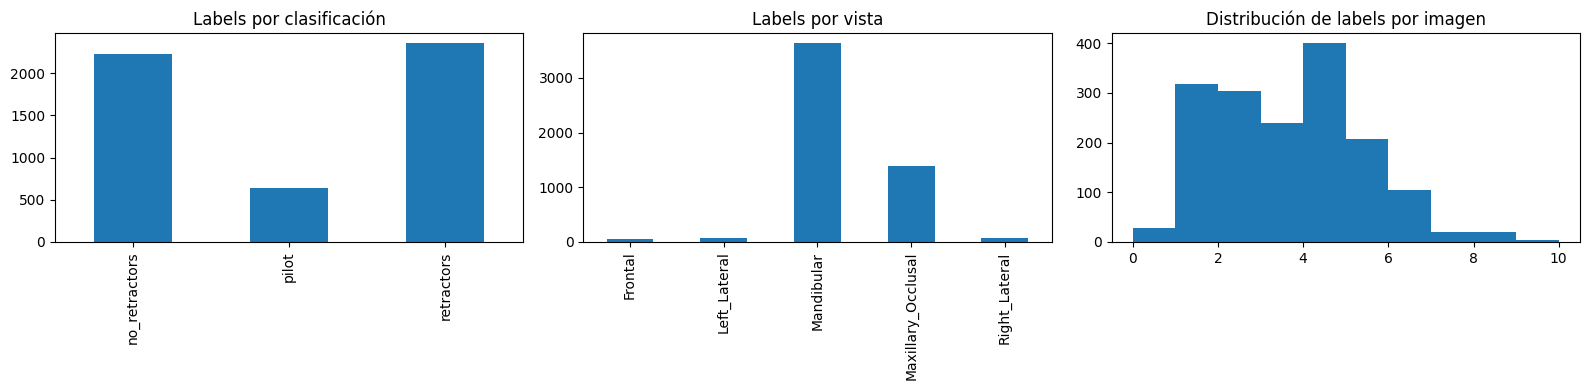

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pd.Series(label_counts_by_class).plot(kind="bar", ax=axes[0], title="Labels por clasificación")
pd.Series(label_counts_by_view).plot(kind="bar", ax=axes[1], title="Labels por vista")
axes[2].hist(labels_per_image, bins=range(0, max(labels_per_image) + 2))
axes[2].set_title("Distribución de labels por imagen")
plt.tight_layout()
plt.show()

## 5. LabelMe to YOLO Conversion (Detection)

In [ ]:
def polygon_to_bbox(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return min(xs), min(ys), max(xs), max(ys)

def labelme_to_yolo_lines(json_path: Path, img_w: int, img_h: int):
    _, shapes = load_labelme_shapes(json_path)
    lines = []
    for shape in shapes:
        label = shape.get("label", "Caries")
        # única clase del dataset -> siempre id 0, pero validamos por consistencia
        cls_id = 0 if label.lower() == "caries" else CLASS_NAMES.index(label) if label in CLASS_NAMES else 0

        pts = shape.get("points", [])
        if shape.get("shape_type") == "rectangle" and len(pts) == 2:
            (x1, y1), (x2, y2) = pts
        else:
            x1, y1, x2, y2 = polygon_to_bbox(pts)

        x1, x2 = sorted((max(0, x1), min(img_w, x2)))
        y1, y2 = sorted((max(0, y1), min(img_h, y2)))
        bw, bh = x2 - x1, y2 - y1
        if bw <= 0 or bh <= 0:
            continue
        xc, yc = x1 + bw / 2, y1 + bh / 2
        lines.append(f"{cls_id} {xc/img_w:.6f} {yc/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}")
    return lines

YOLO_ROOT = RUNTIME_ROOT / "yolo_dataset"
for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

for rec in quality_ok:
    lines = labelme_to_yolo_lines(rec["json_path"], rec["width"], rec["height"])
    rec["yolo_lines"] = lines

# data.yaml apuntando a las carpetas por split (formato estándar Ultralytics YOLO)
with open(YOLO_ROOT / "data.yaml", "w") as f:
    f.write(
        "path: .\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names: {CLASS_NAMES}\n"
    )

print("Ejemplo de líneas YOLO:", quality_ok[0]["yolo_lines"][:3])

Ejemplo de líneas YOLO: ['0 0.207600 0.581371 0.083815 0.135619']


## 6. Train/Validation/Test Split (Stratified by Classification + View)

In [ ]:
from sklearn.model_selection import train_test_split

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

# Clave de estratificación: combinación classification+view, para preservar
# la proporción de cada una de las 3 clasificaciones y las 5 vistas en cada split.
for rec in quality_ok:
    rec["strata"] = f"{rec['classification']}__{rec['view']}"

strata_counts = Counter(rec["strata"] for rec in quality_ok)
# sklearn stratify exige al menos 2 muestras por estrato en cada partición;
# si algún estrato queda muy chico, se cae a split simple para ese grupo.
valid_strata = {k for k, v in strata_counts.items() if v >= 3}
recs_stratifiable = [r for r in quality_ok if r["strata"] in valid_strata]
recs_leftover = [r for r in quality_ok if r["strata"] not in valid_strata]

if recs_leftover:
    print(f"Aviso: {len(recs_leftover)} imágenes en estratos con <3 muestras; "
          f"se reparten con split aleatorio simple (no estratificado).")

def split_records(recs, strat_key_ok):
    labels = [r["strata"] for r in recs] if strat_key_ok else None
    train_recs, temp_recs = train_test_split(
        recs, test_size=(VAL_RATIO + TEST_RATIO), random_state=42,
        stratify=labels)
    if strat_key_ok:
        temp_labels = [r["strata"] for r in temp_recs]
    else:
        temp_labels = None
    rel_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    val_recs, test_recs = train_test_split(
        temp_recs, test_size=rel_test, random_state=42,
        stratify=temp_labels)
    return train_recs, val_recs, test_recs

train_a, val_a, test_a = split_records(recs_stratifiable, strat_key_ok=True) if recs_stratifiable else ([], [], [])
train_b, val_b, test_b = split_records(recs_leftover, strat_key_ok=False) if recs_leftover else ([], [], [])

train_recs = train_a + train_b
val_recs = val_a + val_b
test_recs = test_a + test_b

for split_name, split_recs in [("train", train_recs), ("val", val_recs), ("test", test_recs)]:
    for r in split_recs:
        r["split"] = split_name

print(f"train={len(train_recs)}  val={len(val_recs)}  test={len(test_recs)}  "
      f"(total={len(train_recs)+len(val_recs)+len(test_recs)})")

train=1151  val=247  test=247  (total=1645)


In [ ]:
# Verificación de la distribución por split, clasificación y vista
df_split_check = pd.DataFrame(quality_ok)[["classification", "view", "split"]]
dist_table = pd.crosstab([df_split_check["classification"], df_split_check["view"]],
                          df_split_check["split"], normalize="index") * 100
display(dist_table.round(1))

dist_counts = pd.crosstab([df_split_check["classification"], df_split_check["view"]],
                           df_split_check["split"])
display(dist_counts)

split                              test  train   val
classification view                                 
no_retractors  Frontal             12.5   68.8  18.8
               Left_Lateral        15.0   70.0  15.0
               Mandibular          15.0   70.0  15.0
               Maxillary_Occlusal  14.8   69.8  15.4
               Right_Lateral       14.8   70.4  14.8
pilot          Frontal             17.6   70.6  11.8
               Left_Lateral        14.3   71.4  14.3
               Mandibular          15.6   69.7  14.8
               Maxillary_Occlusal  15.3   69.5  15.3
               Right_Lateral       14.3   71.4  14.3
retractors     Frontal             17.4   69.6  13.0
               Left_Lateral        13.0   69.6  17.4
               Mandibular          15.1   70.0  14.9
               Maxillary_Occlusal  15.0   69.9  15.0
               Right_Lateral       11.1   72.2  16.7

split                              test  train  val
classification view                                
no_retractors  Frontal                2     11    3
               Left_Lateral           3     14    3
               Mandibular            68    318   68
               Maxillary_Occlusal    25    118   26
               Right_Lateral          4     19    4
pilot          Frontal                3     12    2
               Left_Lateral           2     10    2
               Mandibular            19     85   18
               Maxillary_Occlusal     9     41    9
               Right_Lateral          2     10    2
retractors     Frontal                4     16    3
               Left_Lateral           3     16    4
               Mandibular            70    324   69
               Maxillary_Occlusal    31    144   31
               Right_Lateral          2     13    3

## 7. Image Preprocessing

Functions taken directly from the provided preprocessing module (same logic, no modifications).

In [ ]:
# ── helper ────────────────────────────────────────────────────────────────────
def _odd(n: int) -> int:
    """Retorna n si es impar, n+1 si es par. Igual que APP-Filtering."""
    return n if n % 2 == 1 else n + 1


def op_white_balance(image, method="shades_of_gray", percentile=95.0,
                      shades_p=4.0, saturation_threshold=0.98):
    img_f = image.astype(np.float64)
    norms = []
    for c in range(3):
        ch = img_f[:, :, c].ravel()
        ch = ch[ch > 1e-3]
        norms.append(1.0 if len(ch) == 0 else float((np.mean(ch ** shades_p)) ** (1.0 / shades_p)))
    mean_norm = float(np.mean(norms))
    result = img_f.copy()
    for c in range(3):
        n = norms[c] if norms[c] > 0 else 1.0
        result[:, :, c] = np.clip(img_f[:, :, c] * (mean_norm / n), 0.0, 255.0)
    return result.astype(np.uint8)


def op_clahe(image, color_space="LAB", clip_limit=2.0, tile_grid_size=8, kernel_size=0):
    tile = (int(tile_grid_size[0]), int(tile_grid_size[-1])) if isinstance(tile_grid_size, (list, tuple)) \
        else (int(tile_grid_size), int(tile_grid_size))
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile)
    if color_space.upper() == "LAB":
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        return cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)
    elif color_space.upper() == "HSV":
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)
        return cv2.cvtColor(cv2.merge([h, s, clahe.apply(v)]), cv2.COLOR_HSV2BGR)
    else:
        channels = list(cv2.split(image))
        return cv2.merge([clahe.apply(c) for c in channels])


def op_specular_highlight(image, method="attenuate", value_threshold=245,
                           saturation_threshold=60, dilate=8, inpaint_radius=8, attenuation=0.7):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    rgb_peak = image.max(axis=2)
    mask = (((hsv[:, :, 2] >= value_threshold) & (hsv[:, :, 1] <= saturation_threshold)) |
            (rgb_peak >= value_threshold)).astype(np.uint8)
    if dilate > 0:
        k = _odd(dilate)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        mask = cv2.dilate(mask, kernel, iterations=1)
    if method == "inpaint":
        return cv2.inpaint(image, mask, inpaint_radius, cv2.INPAINT_TELEA)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    L, a_ch, b_ch = cv2.split(lab)
    L_f = L.astype(np.float32)
    sigma = float(_odd(dilate))
    L_blur = cv2.GaussianBlur(L_f, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
    alpha = mask.astype(np.float32) * attenuation
    L_new = np.clip(L_f * (1.0 - alpha) + L_blur * alpha, 0, 255).astype(np.uint8)
    return cv2.cvtColor(cv2.merge([L_new, a_ch, b_ch]), cv2.COLOR_LAB2BGR)


def op_edges(image, method="laplacian", kernel_size=7, threshold1=83, threshold2=163,
             strength=0.05, overlay=True):
    ksize_odd = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (ksize_odd, ksize_odd), 0)
    if method == "laplacian":
        lap_ksize = min(ksize_odd, 7)
        lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=lap_ksize)
        edge = np.abs(lap)
        norm = np.zeros_like(edge)
        cv2.normalize(edge, norm, 0, 255, cv2.NORM_MINMAX)
        edge = norm.astype(np.uint8)
    else:
        edge = cv2.Canny(blurred, threshold1, threshold2)
    if not overlay:
        return cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
    edge_bgr = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR).astype(np.float32)
    result = image.astype(np.float32) + strength * edge_bgr
    return np.clip(result, 0, 255).astype(np.uint8)


def op_denoise(image, method="median_blur", kernel_size=3, diameter=7, sigma_color=120,
                sigma_space=120, h=6.5, template_window=7, search_window=21,
                guided_radius=8, guided_eps=0.02):
    ksize = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    if method == "median_blur":
        return cv2.medianBlur(image, ksize)
    elif method == "bilateral":
        return cv2.bilateralFilter(image, d=diameter, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    elif method == "nlm":
        return cv2.fastNlMeansDenoisingColored(image, None, h=h, hColor=h,
                                                templateWindowSize=template_window, searchWindowSize=search_window)
    elif method == "gaussian":
        return cv2.GaussianBlur(image, (ksize, ksize), 0)
    elif method == "guided":
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        from scipy.ndimage import uniform_filter
        result_chs = []
        for ch in range(image.shape[2]):
            src = image[:, :, ch].astype(np.float32) / 255.0
            mean_I = uniform_filter(gray, guided_radius)
            mean_p = uniform_filter(src, guided_radius)
            mean_Ip = uniform_filter(gray * src, guided_radius)
            cov_Ip = mean_Ip - mean_I * mean_p
            mean_II = uniform_filter(gray * gray, guided_radius)
            var_I = mean_II - mean_I * mean_I
            a_coef = cov_Ip / (var_I + guided_eps)
            b_coef = mean_p - a_coef * mean_I
            mean_a = uniform_filter(a_coef, guided_radius)
            mean_b = uniform_filter(b_coef, guided_radius)
            q = np.clip((mean_a * gray + mean_b) * 255, 0, 255).astype(np.uint8)
            result_chs.append(q)
        return cv2.merge(result_chs)
    return image


def op_brightness_contrast(image, brightness=0, contrast=1.0):
    return cv2.convertScaleAbs(image, alpha=contrast, beta=brightness)


_OP_MAP = {
    "white_balance": op_white_balance,
    "clahe": op_clahe,
    "specular_highlight": op_specular_highlight,
    "edges": op_edges,
    "denoise": op_denoise,
    "brightness_contrast": op_brightness_contrast,
    "bilateral_filter": lambda img, **kw: cv2.bilateralFilter(
        img, d=kw.get("d", 9), sigmaColor=kw.get("sigma_color", 75), sigmaSpace=kw.get("sigma_space", 75)),
}


def apply_pipeline(image, pipeline):
    result = image.copy()
    for step in pipeline:
        op_name = step["op"]
        params = {k: v for k, v in step.items() if k != "op"}
        fn = _OP_MAP.get(op_name)
        if fn is None:
            raise ValueError(f"Operación no reconocida: '{op_name}'")
        result = fn(result, **params)
    return result

In [ ]:
PREPROCESSING_PIPELINE = [
    {"op": "white_balance", "method": "shades_of_gray", "percentile": 95.0,
     "shades_p": 4.0, "saturation_threshold": 0.98},
    {"op": "clahe", "color_space": "LAB", "clip_limit": 1.3,
     "tile_grid_size": [8, 8], "kernel_size": 31},
    {"op": "specular_highlight", "method": "attenuate", "value_threshold": 245,
     "saturation_threshold": 60, "dilate": 8, "inpaint_radius": 8, "attenuation": 0.7},
    {"op": "edges", "method": "laplacian", "kernel_size": 7, "threshold1": 83,
     "threshold2": 163, "strength": 0.05, "overlay": True},
    {"op": "denoise", "method": "median_blur", "kernel_size": 3},
    {"op": "brightness_contrast", "brightness": -5, "contrast": 1.0},
]

print("Pipeline configurado con", len(PREPROCESSING_PIPELINE), "operaciones:")
for step in PREPROCESSING_PIPELINE:
    print(f"  [{step['op']}] {step}")

Pipeline configurado con 6 operaciones:
  [white_balance] {'op': 'white_balance', 'method': 'shades_of_gray', 'percentile': 95.0, 'shades_p': 4.0, 'saturation_threshold': 0.98}
  [clahe] {'op': 'clahe', 'color_space': 'LAB', 'clip_limit': 1.3, 'tile_grid_size': [8, 8], 'kernel_size': 31}
  [specular_highlight] {'op': 'specular_highlight', 'method': 'attenuate', 'value_threshold': 245, 'saturation_threshold': 60, 'dilate': 8, 'inpaint_radius': 8, 'attenuation': 0.7}
  [edges] {'op': 'edges', 'method': 'laplacian', 'kernel_size': 7, 'threshold1': 83, 'threshold2': 163, 'strength': 0.05, 'overlay': True}
  [denoise] {'op': 'denoise', 'method': 'median_blur', 'kernel_size': 3}
  [brightness_contrast] {'op': 'brightness_contrast', 'brightness': -5, 'contrast': 1.0}


In [ ]:
# Aplicar el pipeline a cada imagen del set final y escribir imagen + label YOLO
for rec in quality_ok:
    img = cv2.imread(str(rec["image_path"]))
    processed = apply_pipeline(img, PREPROCESSING_PIPELINE)

    out_name = f"{rec['classification']}_{rec['view']}_{rec['stem']}"
    out_img_path = YOLO_ROOT / "images" / rec["split"] / f"{out_name}{rec['image_path'].suffix.lower()}"
    out_lbl_path = YOLO_ROOT / "labels" / rec["split"] / f"{out_name}.txt"

    cv2.imwrite(str(out_img_path), processed)
    with open(out_lbl_path, "w") as f:
        f.write("\n".join(rec["yolo_lines"]))

    rec["processed_path"] = out_img_path

print("Imágenes preprocesadas y exportadas a formato YOLO:", len(quality_ok))

Imágenes preprocesadas y exportadas a formato YOLO: 1645


## 8. Random Before-and-After Samples

In [ ]:
sample_recs = random.sample(quality_ok, k=min(4, len(quality_ok)))

fig, axes = plt.subplots(len(sample_recs), 2, figsize=(10, 4 * len(sample_recs)))
if len(sample_recs) == 1:
    axes = [axes]

for row, rec in zip(axes, sample_recs):
    before = cv2.cvtColor(cv2.imread(str(rec["image_path"])), cv2.COLOR_BGR2RGB)
    after = cv2.cvtColor(cv2.imread(str(rec["processed_path"])), cv2.COLOR_BGR2RGB)
    row[0].imshow(before); row[0].set_title(f"Antes: {rec['stem']}"); row[0].axis("off")
    row[1].imshow(after); row[1].set_title(f"Después: {rec['stem']}"); row[1].axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9. Final Packaging and Upload to Drive

In [ ]:
zip_buffer = io.BytesIO()
with zipfile.ZipFile(zip_buffer, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in YOLO_ROOT.rglob("*"):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(YOLO_ROOT))

zip_buffer.seek(0)
# Ensure the parent directory exists before writing the file
Path(OUTPUT_ZIP_DRIVE_PATH).parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_ZIP_DRIVE_PATH, "wb") as f:
    f.write(zip_buffer.read())

print("Dataset final exportado a:", OUTPUT_ZIP_DRIVE_PATH)

Dataset final exportado a: /content/drive/MyDrive/UNIVERSIDAD/9NO SEMESTRE/TITULACION/DATASET CARIES/Dataset Tratado 1/Dataset-Filtrado.zip


In [ ]:
# Final Audit Summary
print("Registros originales candidatos:", len(records))
print("Descartados sin label:", len(audit_discarded["sin_label"]))
print("Jsons sin imagen:", len(audit_discarded["sin_imagen"]))
print("Descartados por calidad (resolución/blur):", len(quality_discarded))
print("Dataset final (imágenes+labels YOLO):", len(quality_ok))
print("Total labels Caries en dataset final:", sum(r["n_labels"] for r in quality_ok))

print("\nPor split:")
for split_name in ["train", "val", "test"]:
    split_recs = [r for r in quality_ok if r["split"] == split_name]
    print(f"  {split_name}: {len(split_recs)} imágenes, "
          f"{sum(r['n_labels'] for r in split_recs)} labels")

Registros originales candidatos: 2227
Descartados sin label: 4038
Jsons sin imagen: 18
Descartados por calidad (resolución/blur): 582
Dataset final (imágenes+labels YOLO): 1645
Total labels Caries en dataset final: 5237

Por split:
  train: 1151 imágenes, 3620 labels
  val: 247 imágenes, 827 labels
  test: 247 imágenes, 790 labels
